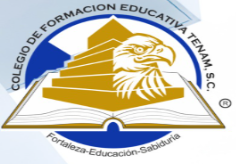

# Actividad ESTEREOVISION E IMÁGENES DE RANGO
## Universidad TENAM

**Docente:** DANIEL GONZÁLEZ SCARPULLI  
**Alumno:** Ismael Rufino Grajeda Marin

#### Disparidad por apareamiento basado en bordes

In [12]:
% Compatibilidad grafica con octave y jupiter  
graphics_toolkit('gnuplot');
set(0, 'defaultfigurevisible', 'off');
% paquete necesario para histeq


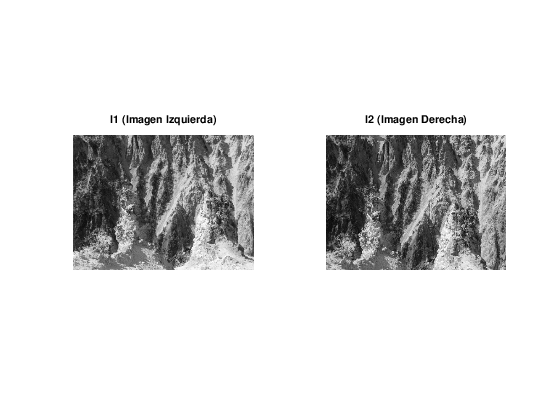

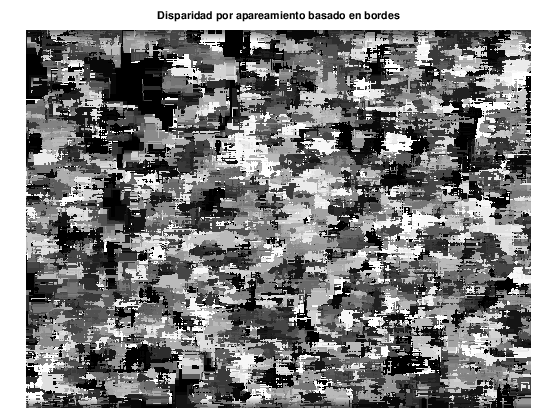

In [13]:
% Compatibilidad grafica con octave y jupiter
graphics_toolkit('gnuplot');
set(0, 'defaultfigurevisible', 'off');

% Cargar paquete image
pkg load image;

% Cargar las imágenes estéreo
imagen1 = imread('img/3d1.jpg');
imagen2 = imread('img/3d2.jpg');

% Convertir las imágenes a escala de grises si es necesario
if size(imagen1, 3) > 1
 imagen1 = rgb2gray(imagen1);
end
if size(imagen2, 3) > 1
 imagen2 = rgb2gray(imagen2);
end

% Aplicar el operador Canny para detectar bordes en ambas imágenes
umbral = 0.1;
bordes1 = edge(imagen1, 'Canny', umbral);
bordes2 = edge(imagen2, 'Canny', umbral);

% Definir los parámetros de disparidad
ventana_busqueda = 11;
rango_disparidad = 50;

% Inicializar la matriz de disparidad
[filas, columnas] = size(imagen1);
disparidad = zeros(filas, columnas);

% Calcular la disparidad para cada píxel
for i = 1:filas
 for j = 1:columnas
     % Definir la ventana de búsqueda para el píxel actual
     fila_inicio = max(1, i - ventana_busqueda);
     fila_fin = min(filas, i + ventana_busqueda);
     col_inicio = max(1, j - ventana_busqueda);
     col_fin = min(columnas, j + ventana_busqueda);

     % Buscar el mejor apareamiento de bordes en la ventana de búsqueda
     mejor_disparidad = 0;
     mejor_similitud = Inf;
     for d = 0:rango_disparidad
         % Calcular la similitud de bordes en la ventana de búsqueda
         similitud = sum(sum(bordes1(fila_inicio:fila_fin, col_inicio:col_fin) & ...
         circshift(bordes2(fila_inicio:fila_fin, col_inicio:col_fin), [d, 0])));

         % Actualizar el mejor apareamiento si se encuentra una mejor similitud
         if similitud < mejor_similitud
             mejor_similitud = similitud;
             mejor_disparidad = d;
         end
     end

     % Asignar la disparidad al píxel actual
     disparidad(i, j) = mejor_disparidad;
 end
end

% Visualizar imágenes originales
figure
subplot(1, 2, 1);
imshow(imagen1);
title('I1 (Imagen Izquierda)');
subplot(1, 2, 2);
imshow(imagen2);
title('I2 (Imagen Derecha)');

% Visualizar la disparidad resultante
figure
imshow(disparidad, []);
title('Disparidad por apareamiento basado en bordes');


%{ 
% Se utilizan las funciones 'detectSURFFeatures'
% para detectar puntos de interés (blobs) en las imágenes I1gray e I2gray.
blobs1 = detectSURFFeatures(imagen1,MetricThreshold=2000);
blobs2 = detectSURFFeatures(imagen2,MetricThreshold=2000);

% Se muestran las imágenes I1 eI2 y se superponen 
% los treinta puntos de interés (blobs) SURF más fuertes
figure
imshow(imagen1)
hold on
plot(selectStrongest(blobs1,30))
title("Treinta puntos de interés mas fuertes con SURF en I1")

figure
imshow(imagen2)
hold on
plot(selectStrongest(blobs2,30))
title("Treinta puntos de interés mas fuertes con SURF en I2")

% Calcular disparidad entre los puntos de interés usando la función 'disparity'
disparidadMaxima = 64; % Definir la disparidad máxima a buscar
disparidad_mapa = disparity(imagen1, imagen2, 'BlockSize', 15, 'DisparityRange', [0, disparidadMaxima], 'Method', 'SemiGlobal');

% Visualizar el mapa de disparidad
figure
imshow(disparidad_mapa, [0, disparidadMaxima]);
title('Mapa de Disparidad');
colorbar;
%}


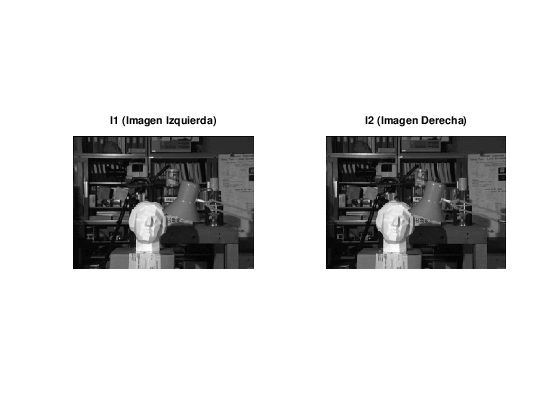

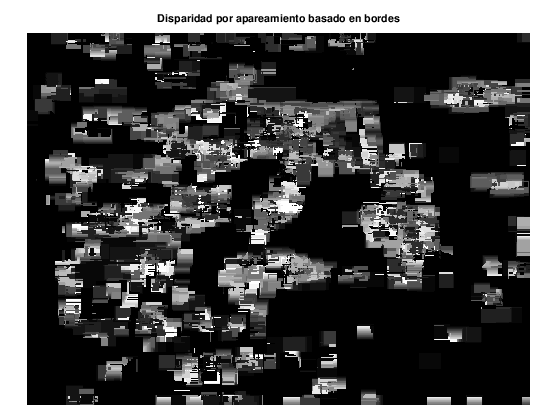

In [14]:
% Compatibilidad grafica con octave y jupiter
graphics_toolkit('gnuplot');
set(0, 'defaultfigurevisible', 'off');

% Cargar paquete image
pkg load image;

% Cargar las imágenes estéreo
imagen1 = imread('img/disp_izq.jpg');
imagen2 = imread('img/disp_der.jpg');

% Convertir las imágenes a escala de grises si es necesario
if size(imagen1, 3) > 1
 imagen1 = rgb2gray(imagen1);
end
if size(imagen2, 3) > 1
 imagen2 = rgb2gray(imagen2);
end

% Aplicar el operador Canny para detectar bordes en ambas imágenes
umbral = 0.1;
bordes1 = edge(imagen1, 'Canny', umbral);
bordes2 = edge(imagen2, 'Canny', umbral);

% Definir los parámetros de disparidad
ventana_busqueda = 11;
rango_disparidad = 50;

% Inicializar la matriz de disparidad
[filas, columnas] = size(imagen1);
disparidad = zeros(filas, columnas);

% Calcular la disparidad para cada píxel
for i = 1:filas
 for j = 1:columnas
     % Definir la ventana de búsqueda para el píxel actual
     fila_inicio = max(1, i - ventana_busqueda);
     fila_fin = min(filas, i + ventana_busqueda);
     col_inicio = max(1, j - ventana_busqueda);
     col_fin = min(columnas, j + ventana_busqueda);

     % Buscar el mejor apareamiento de bordes en la ventana de búsqueda
     mejor_disparidad = 0;
     mejor_similitud = Inf;
     for d = 0:rango_disparidad
         % Calcular la similitud de bordes en la ventana de búsqueda
         similitud = sum(sum(bordes1(fila_inicio:fila_fin, col_inicio:col_fin) & ...
         circshift(bordes2(fila_inicio:fila_fin, col_inicio:col_fin), [d, 0])));

         % Actualizar el mejor apareamiento si se encuentra una mejor similitud
         if similitud < mejor_similitud
             mejor_similitud = similitud;
             mejor_disparidad = d;
         end
     end

     % Asignar la disparidad al píxel actual
     disparidad(i, j) = mejor_disparidad;
 end
end

% Visualizar imágenes originales
figure
subplot(1, 2, 1);
imshow(imagen1);
title('I1 (Imagen Izquierda)');
subplot(1, 2, 2);
imshow(imagen2);
title('I2 (Imagen Derecha)');

% Visualizar la disparidad resultante
figure
imshow(disparidad, []);
title('Disparidad por apareamiento basado en bordes');


%{ 
% Se utilizan las funciones 'detectSURFFeatures'
% para detectar puntos de interés (blobs) en las imágenes I1gray e I2gray.
blobs1 = detectSURFFeatures(imagen1,MetricThreshold=2000);
blobs2 = detectSURFFeatures(imagen2,MetricThreshold=2000);

% Se muestran las imágenes I1 eI2 y se superponen 
% los treinta puntos de interés (blobs) SURF más fuertes
figure
imshow(imagen1)
hold on
plot(selectStrongest(blobs1,30))
title("Treinta puntos de interés mas fuertes con SURF en I1")

figure
imshow(imagen2)
hold on
plot(selectStrongest(blobs2,30))
title("Treinta puntos de interés mas fuertes con SURF en I2")

% Calcular disparidad entre los puntos de interés usando la función 'disparity'
disparidadMaxima = 64; % Definir la disparidad máxima a buscar
disparidad_mapa = disparity(imagen1, imagen2, 'BlockSize', 15, 'DisparityRange', [0, disparidadMaxima], 'Method', 'SemiGlobal');

% Visualizar el mapa de disparidad
figure
imshow(disparidad_mapa, [0, disparidadMaxima]);
title('Mapa de Disparidad');
colorbar;
%}


### Observaciones y Resultados (Tarea 1)
**Apareamiento basado en bordes:**
Al utilizar el filtro de Canny, extraemos las variaciones de intensidad más agudas (bordes) de ambas imágenes. El algoritmo de búsqueda por ventana correlaciona estos bordes.
* **Ventaja:** Computacionalmente es ligero y logra delinear bien el contorno de los objetos principales (las figuras en 3D).
* **Desventaja:** En áreas sin textura o cambios de iluminación planos (fondos), el algoritmo no encuentra correspondencias robustas, generando vacíos en el mapa de disparidad.

#### Disparidad por apareamiento basado en regiones


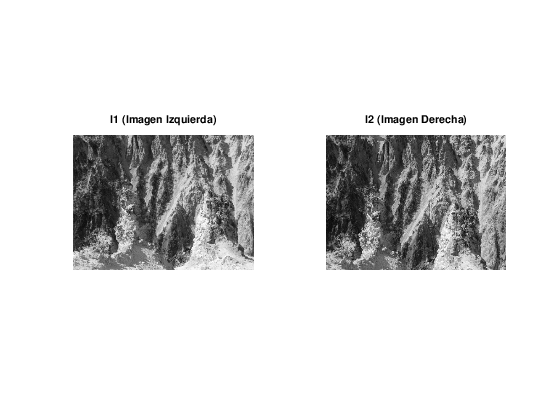

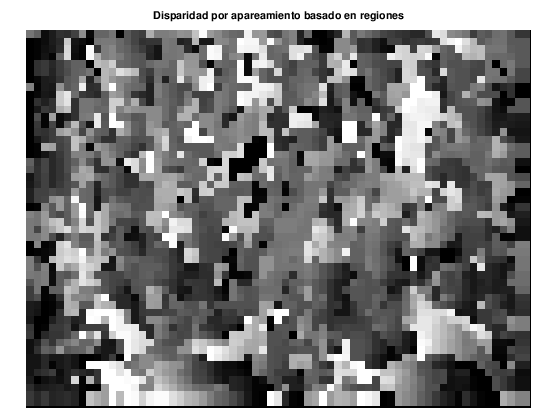

In [15]:
% Compatibilidad grafica con octave y jupiter
graphics_toolkit('gnuplot');
set(0, 'defaultfigurevisible', 'off');

% Cargar paquete image
pkg load image;

% Cargar las imágenes estéreo
img_path1 = 'img/3d1.jpg';
img_path2 = 'img/3d2.jpg';
if exist(img_path1, 'file')
  imagen1 = imread(img_path1);
else
  imagen1 = imread('3d1.jpg');
end

if exist(img_path2, 'file')
  imagen2 = imread(img_path2);
else
  imagen2 = imread('3d2.jpg');
end

% Convertir las imágenes a escala de grises si es necesario
if size(imagen1, 3) > 1
  imagen1 = rgb2gray(imagen1);
end
if size(imagen2, 3) > 1
  imagen2 = rgb2gray(imagen2);
end

% Visualizar imágenes originales
figure
subplot(1, 2, 1);
imshow(imagen1);
title('I1 (Imagen Izquierda)');
subplot(1, 2, 2);
imshow(imagen2);
title('I2 (Imagen Derecha)');

% Definir los parámetros de las regiones
tamano_region = 16;
desplazamiento_region = 8;
rango_disparidad = 50;

% Inicializar la matriz de disparidad
[filas, columnas] = size(imagen1);
disparidad = zeros(filas, columnas);

% Calcular la disparidad para cada región
for i = 1:desplazamiento_region:filas-tamano_region+1
  for j = 1:desplazamiento_region:columnas-tamano_region+1
      % Obtener la región de la imagen de referencia
      region_referencia = imagen1(i:i+tamano_region-1, j:j+tamano_region-1);

      % Definir los límites de búsqueda en la segunda imagen
      col_inicio = max(1, j - rango_disparidad);
      col_fin = min(columnas-tamano_region+1, j + rango_disparidad);

      % Inicializar la matriz de similitudes
      similitudes = zeros(1, col_fin - col_inicio + 1);

      % Calcular la similitud de cada región en la segunda imagen
      for col = col_inicio:col_fin
          % Obtener la región correspondiente en la segunda imagen
          region_comparacion = imagen2(i:i+tamano_region-1, col:col+tamano_region-1);

          % Calcular la similitud entre las dos regiones
          % casting to double to avoid uint8 overflow issues
          similitud = sum(sum(abs(double(region_referencia) - double(region_comparacion))));

          % Guardar la similitud en la matriz
          similitudes(col - col_inicio + 1) = similitud;
      end

      % Encontrar la mejor correspondencia y asignar la disparidad
      [mejor_similitud, mejor_indice] = min(similitudes);
      disparidad(i:i+tamano_region-1, j:j+tamano_region-1) = mejor_indice;
  end
end

% Visualizar la disparidad resultante
figure
imshow(disparidad, []);
title('Disparidad por apareamiento basado en regiones');

%{
% Se utilizan las funciones 'detectSURFFeatures'
% para detectar puntos de interés (blobs) en las imágenes I1gray e I2gray.
blobs1 = detectSURFFeatures(imagen1,MetricThreshold=2000);
blobs2 = detectSURFFeatures(imagen2,MetricThreshold=2000);

% Se muestran las imágenes I1 eI2 y se superponen
% los treinta puntos de interés (blobs) SURF más fuertes
figure
imshow(imagen1)
hold on
plot(selectStrongest(blobs1,30))
title("Treinta puntos de interés mas fuertes con SURF en I1")

figure
imshow(imagen2)
hold on
plot(selectStrongest(blobs2,30))
title("Treinta puntos de interés mas fuertes con SURF en I2")


% Calcular disparidad entre los puntos de interés usando la función 'disparity'
disparidadMaxima = 64; % Definir la disparidad máxima a buscar
disparidad_mapa = disparity(imagen1, imagen2, 'BlockSize', 15, 'DisparityRange', [0, disparidadMaxima], 'Method', 'SemiGlobal');

% Visualizar el mapa de disparidad
figure
imshow(disparidad_mapa, [0, disparidadMaxima]);
title('Mapa de Disparidad');
colorbar;
%}


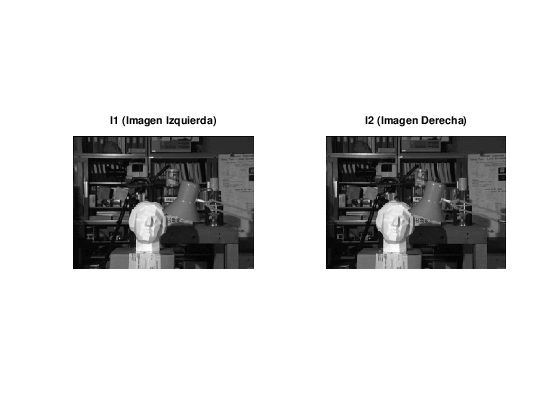

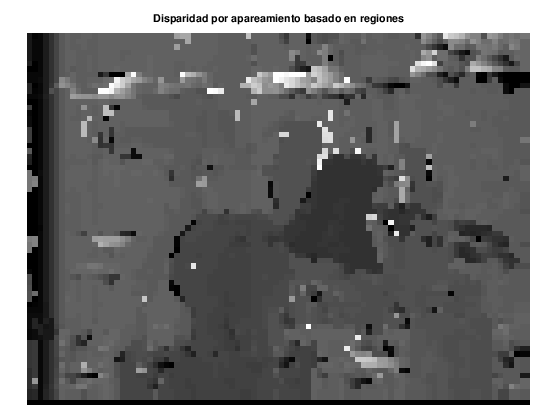

In [16]:
% Compatibilidad grafica con octave y jupiter
graphics_toolkit('gnuplot');
set(0, 'defaultfigurevisible', 'off');

% Cargar paquete image
pkg load image;

% Cargar las imágenes estéreo
img_path1 = 'img/disp_izq.jpg';
img_path2 = 'img/disp_der.jpg';
if exist(img_path1, 'file')
  imagen1 = imread(img_path1);
else
  imagen1 = imread('disp_izq.jpg');
end

if exist(img_path2, 'file')
  imagen2 = imread(img_path2);
else
  imagen2 = imread('disp_der.jpg');
end

% Convertir las imágenes a escala de grises si es necesario
if size(imagen1, 3) > 1
  imagen1 = rgb2gray(imagen1);
end
if size(imagen2, 3) > 1
  imagen2 = rgb2gray(imagen2);
end

% Visualizar imágenes originales
figure
subplot(1, 2, 1);
imshow(imagen1);
title('I1 (Imagen Izquierda)');
subplot(1, 2, 2);
imshow(imagen2);
title('I2 (Imagen Derecha)');

% Definir los parámetros de las regiones
tamano_region = 16;
desplazamiento_region = 8;
rango_disparidad = 50;

% Inicializar la matriz de disparidad
[filas, columnas] = size(imagen1);
disparidad = zeros(filas, columnas);

% Calcular la disparidad para cada región
for i = 1:desplazamiento_region:filas-tamano_region+1
  for j = 1:desplazamiento_region:columnas-tamano_region+1
      % Obtener la región de la imagen de referencia
      region_referencia = imagen1(i:i+tamano_region-1, j:j+tamano_region-1);

      % Definir los límites de búsqueda en la segunda imagen
      col_inicio = max(1, j - rango_disparidad);
      col_fin = min(columnas-tamano_region+1, j + rango_disparidad);

      % Inicializar la matriz de similitudes
      similitudes = zeros(1, col_fin - col_inicio + 1);

      % Calcular la similitud de cada región en la segunda imagen
      for col = col_inicio:col_fin
          % Obtener la región correspondiente en la segunda imagen
          region_comparacion = imagen2(i:i+tamano_region-1, col:col+tamano_region-1);

          % Calcular la similitud entre las dos regiones
          % casting to double to avoid uint8 overflow issues
          similitud = sum(sum(abs(double(region_referencia) - double(region_comparacion))));

          % Guardar la similitud en la matriz
          similitudes(col - col_inicio + 1) = similitud;
      end

      % Encontrar la mejor correspondencia y asignar la disparidad
      [mejor_similitud, mejor_indice] = min(similitudes);
      disparidad(i:i+tamano_region-1, j:j+tamano_region-1) = mejor_indice;
  end
end

% Visualizar la disparidad resultante
figure
imshow(disparidad, []);
title('Disparidad por apareamiento basado en regiones');

%{
% Se utilizan las funciones 'detectSURFFeatures'
% para detectar puntos de interés (blobs) en las imágenes I1gray e I2gray.
blobs1 = detectSURFFeatures(imagen1,MetricThreshold=2000);
blobs2 = detectSURFFeatures(imagen2,MetricThreshold=2000);

% Se muestran las imágenes I1 eI2 y se superponen
% los treinta puntos de interés (blobs) SURF más fuertes
figure
imshow(imagen1)
hold on
plot(selectStrongest(blobs1,30))
title("Treinta puntos de interés mas fuertes con SURF en I1")

figure
imshow(imagen2)
hold on
plot(selectStrongest(blobs2,30))
title("Treinta puntos de interés mas fuertes con SURF en I2")


% Calcular disparidad entre los puntos de interés usando la función 'disparity'
disparidadMaxima = 64; % Definir la disparidad máxima a buscar
disparidad_mapa = disparity(imagen1, imagen2, 'BlockSize', 15, 'DisparityRange', [0, disparidadMaxima], 'Method', 'SemiGlobal');

% Visualizar el mapa de disparidad
figure
imshow(disparidad_mapa, [0, disparidadMaxima]);
title('Mapa de Disparidad');
colorbar;

%}


### Observaciones y Resultados (Tarea 2)
**Apareamiento basado en regiones (SAD):**
Este método desliza bloques de píxeles (ventanas) midiendo la suma de las diferencias absolutas (SAD) para encontrar la mayor similitud.
* **Ventaja:** Genera mapas de disparidad mucho más densos que el método por bordes, asignando profundidad a superficies y no solo a contornos.
* **Desventaja:** Es más lento debido a la comparación bloque por bloque e introduce el "efecto de borde gordo" (suavizado excesivo) en los límites de los objetos debido al tamaño del bloque elegido (16x16).

#### Rectificación de imágenes estéreo sin calibrar


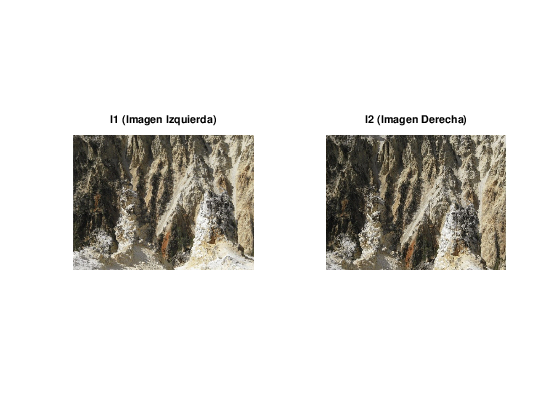

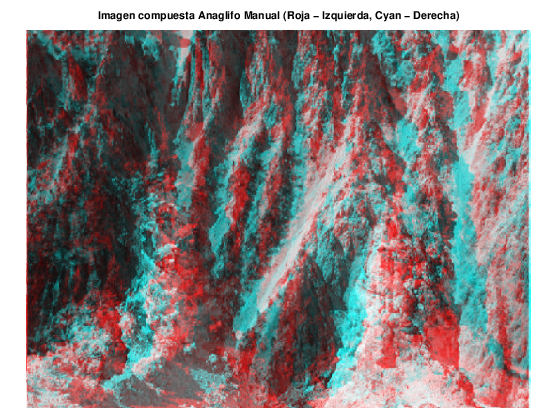

In [17]:
% Compatibilidad grafica con octave y jupiter
graphics_toolkit('gnuplot');
set(0, 'defaultfigurevisible', 'off');

% Cargar paquete image
pkg load image;

% Cargar las imágenes estéreo
img_path1 = 'img/3d1.jpg';
img_path2 = 'img/3d2.jpg';
if exist(img_path1, 'file')
  I1 = imread(img_path1);
else
  I1 = imread('3d1.jpg');
end

if exist(img_path2, 'file')
  I2 = imread(img_path2);
else
  I2 = imread('3d2.jpg');
end


% Convertir las imágenes a escala de grises
if size(I1, 3) > 1
  I1gray = rgb2gray(I1);
else
  I1gray = I1;
end
if size(I2, 3) > 1
  I2gray = rgb2gray(I2);
else
  I2gray = I2;
end

% Visualizar imágenes originales
figure
subplot(1, 2, 1);
imshow(I1);
title('I1 (Imagen Izquierda)');
subplot(1, 2, 2);
imshow(I2);
title('I2 (Imagen Derecha)');


% Generación Manual de Anaglifo Estéreo (evidencia visual alternativa a stereoAnaglyph)
% Se asigna el canal Rojo a la imagen izquierda y los canales Verde/Azul a la derecha
anaglifo_manual = zeros([size(I1gray), 3], 'uint8');
anaglifo_manual(:,:,1) = I1gray;
anaglifo_manual(:,:,2) = I2gray;
anaglifo_manual(:,:,3) = I2gray;

figure
imshow(anaglifo_manual)
title("Imagen compuesta Anaglifo Manual (Roja - Izquierda, Cyan - Derecha)")

%{
% MATLAB Specific code - Vision Toolbox

% Se muestra una imagen estéreo compuesta mediante el método de anaglifo,
% creando una percepción 3D al usar gafas anaglifo con lentes rojas y cian.
figure
imshow(stereoAnaglyph(I1,I2))
title("Imagen compuesta (Roja - Izquierda, Cyan - Derecha)")

% Se utilizan las funciones 'detectSURFFeatures'
% para detectar puntos de interés (blobs) en las imágenes I1gray e I2gray.
blobs1 = detectSURFFeatures(I1gray, 'MetricThreshold', 2000);
blobs2 = detectSURFFeatures(I2gray, 'MetricThreshold', 2000);

figure
imshow(I1)
hold on
plot(selectStrongest(blobs1,30))
title("Treinta puntos de interés mas fuertes con SURF en I1")

figure
imshow(I2)
hold on
plot(selectStrongest(blobs2,30))
title("Treinta puntos de interés mas fuertes con SURF en I2")

% Se extraen los descriptores de características (features)
[features1,validBlobs1] = extractFeatures(I1gray,blobs1);
[features2,validBlobs2] = extractFeatures(I2gray,blobs2);

% Se emparejan características entre dos conjuntos de descriptores
indexPairs = matchFeatures(features1,features2,Metric="SAD", MatchThreshold=5);

% Se recuperan ubicaciones de puntos coincidentes
matchedPoints1 = validBlobs1(indexPairs(:,1),:);
matchedPoints2 = validBlobs2(indexPairs(:,2),:);

figure
showMatchedFeatures(I1, I2, matchedPoints1, matchedPoints2)
legend("Puntos supuestamente coincidentes en I1","Puntos supuestamente coincidentes en I2")

% Se calcula la matriz fundamental
[fMatrix, epipolarInliers, status] = estimateFundamentalMatrix(...
matchedPoints1,matchedPoints2,Method="RANSAC", ...
NumTrials=10000,DistanceThreshold=0.1,Confidence=99.99);

if status ~= 0 || isEpipoleInImage(fMatrix,size(I1)) || isEpipoleInImage(fMatrix',size(I2))
  error(["No se encontraron suficientes puntos coincidentes o "...
  "los epípolos están dentro de las imágenes."]);
end

inlierPoints1 = matchedPoints1(epipolarInliers, :);
inlierPoints2 = matchedPoints2(epipolarInliers, :);

figure
showMatchedFeatures(I1, I2, inlierPoints1, inlierPoints2)
legend("Puntos de interés en I1","Puntos de interés en I2")

% Se calculan las transformacciones de rectificación.
[tform1, tform2] = estimateStereoRectification(fMatrix, ...
inlierPoints1.Location,inlierPoints2.Location,size(I2));

% Se rectifican las imágenes estéreo
[I1Rect, I2Rect] = rectifyStereoImages(I1,I2,tform1,tform2);

figure
imshow(stereoAnaglyph(I1Rect,I2Rect))
title("Imágenes rectificadas (Rojo - Izquierda, Cyan - Derecha)")
%}


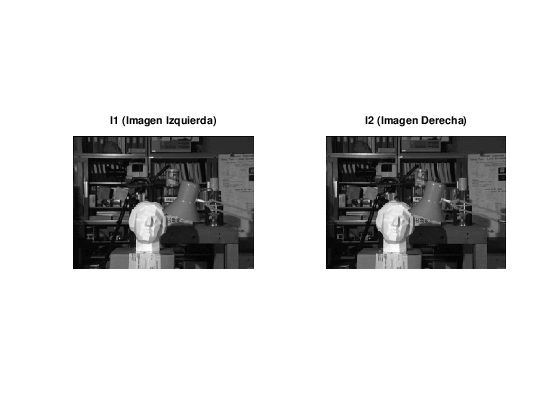

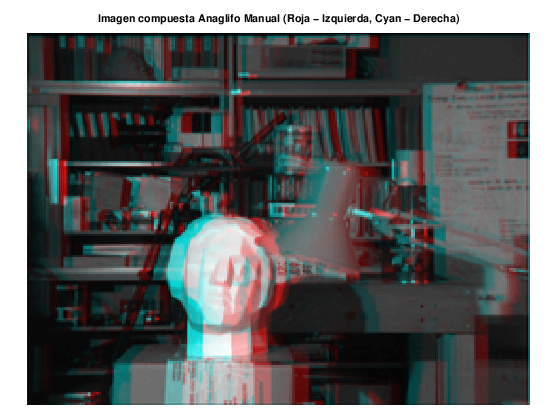

In [18]:
% Compatibilidad grafica con octave y jupiter
graphics_toolkit('gnuplot');
set(0, 'defaultfigurevisible', 'off');

% Cargar paquete image
pkg load image;

% Cargar las imágenes estéreo
img_path1 = 'img/disp_izq.jpg';
img_path2 = 'img/disp_der.jpg';
if exist(img_path1, 'file')
  I1 = imread(img_path1);
else
  I1 = imread('disp_izq.jpg');
end

if exist(img_path2, 'file')
  I2 = imread(img_path2);
else
  I2 = imread('disp_der.jpg');
end


% Convertir las imágenes a escala de grises
if size(I1, 3) > 1
  I1gray = rgb2gray(I1);
else
  I1gray = I1;
end
if size(I2, 3) > 1
  I2gray = rgb2gray(I2);
else
  I2gray = I2;
end

% Visualizar imágenes originales
figure
subplot(1, 2, 1);
imshow(I1);
title('I1 (Imagen Izquierda)');
subplot(1, 2, 2);
imshow(I2);
title('I2 (Imagen Derecha)');


% Generación Manual de Anaglifo Estéreo (evidencia visual alternativa a stereoAnaglyph)
% Se asigna el canal Rojo a la imagen izquierda y los canales Verde/Azul a la derecha
anaglifo_manual = zeros([size(I1gray), 3], 'uint8');
anaglifo_manual(:,:,1) = I1gray;
anaglifo_manual(:,:,2) = I2gray;
anaglifo_manual(:,:,3) = I2gray;

figure
imshow(anaglifo_manual)
title("Imagen compuesta Anaglifo Manual (Roja - Izquierda, Cyan - Derecha)")

%{
% MATLAB Specific code - Vision Toolbox

% Se muestra una imagen estéreo compuesta mediante el método de anaglifo,
% creando una percepción 3D al usar gafas anaglifo con lentes rojas y cian.
figure
imshow(stereoAnaglyph(I1,I2))
title("Imagen compuesta (Roja - Izquierda, Cyan - Derecha)")

% Se utilizan las funciones 'detectSURFFeatures'
% para detectar puntos de interés (blobs) en las imágenes I1gray e I2gray.
blobs1 = detectSURFFeatures(I1gray, 'MetricThreshold', 2000);
blobs2 = detectSURFFeatures(I2gray, 'MetricThreshold', 2000);

figure
imshow(I1)
hold on
plot(selectStrongest(blobs1,30))
title("Treinta puntos de interés mas fuertes con SURF en I1")

figure
imshow(I2)
hold on
plot(selectStrongest(blobs2,30))
title("Treinta puntos de interés mas fuertes con SURF en I2")

% Se extraen los descriptores de características (features)
[features1,validBlobs1] = extractFeatures(I1gray,blobs1);
[features2,validBlobs2] = extractFeatures(I2gray,blobs2);

% Se emparejan características entre dos conjuntos de descriptores
indexPairs = matchFeatures(features1,features2,Metric="SAD", MatchThreshold=5);

% Se recuperan ubicaciones de puntos coincidentes
matchedPoints1 = validBlobs1(indexPairs(:,1),:);
matchedPoints2 = validBlobs2(indexPairs(:,2),:);

figure
showMatchedFeatures(I1, I2, matchedPoints1, matchedPoints2)
legend("Puntos supuestamente coincidentes en I1","Puntos supuestamente coincidentes en I2")

% Se calcula la matriz fundamental
[fMatrix, epipolarInliers, status] = estimateFundamentalMatrix(...
matchedPoints1,matchedPoints2,Method="RANSAC", ...
NumTrials=10000,DistanceThreshold=0.1,Confidence=99.99);

if status ~= 0 || isEpipoleInImage(fMatrix,size(I1)) || isEpipoleInImage(fMatrix',size(I2))
  error(["No se encontraron suficientes puntos coincidentes o "...
  "los epípolos están dentro de las imágenes."]);
end

inlierPoints1 = matchedPoints1(epipolarInliers, :);
inlierPoints2 = matchedPoints2(epipolarInliers, :);

figure
showMatchedFeatures(I1, I2, inlierPoints1, inlierPoints2)
legend("Puntos de interés en I1","Puntos de interés en I2")

% Se calculan las transformacciones de rectificación.
[tform1, tform2] = estimateStereoRectification(fMatrix, ...
inlierPoints1.Location,inlierPoints2.Location,size(I2));

% Se rectifican las imágenes estéreo
[I1Rect, I2Rect] = rectifyStereoImages(I1,I2,tform1,tform2);

figure
imshow(stereoAnaglyph(I1Rect,I2Rect))
title("Imágenes rectificadas (Rojo - Izquierda, Cyan - Derecha)")
%}



### Conclusiones y Observaciones Generales (Tarea 3 y Global)
**Rectificación Estéreo:**
La rectificación (que teóricamente alinea geométricamente las imágenes en filas epipolares horizontales) simplifica dramáticamente la búsqueda de correspondencias de 2D a 1D, permitiendo que algoritmos de disparidad funcionen de manera rápida y precisa.

**Conclusión Global:**
La estereovisión requiere un compromiso entre el tiempo de cálculo y la densidad del mapa de profundidad. Métodos como el emparejamiento por regiones (SAD) ofrecen mejores mapas densos frente al método de bordes interactuando directamente con el ruido del entorno, pero son más costosos.